# 03. Train Demand Forecasting Models
In this notebook, we load the engineered features and train three regressors: XGBoost, Random Forest, and a baseline LSTM.

Loaded 2512267 rows for training.


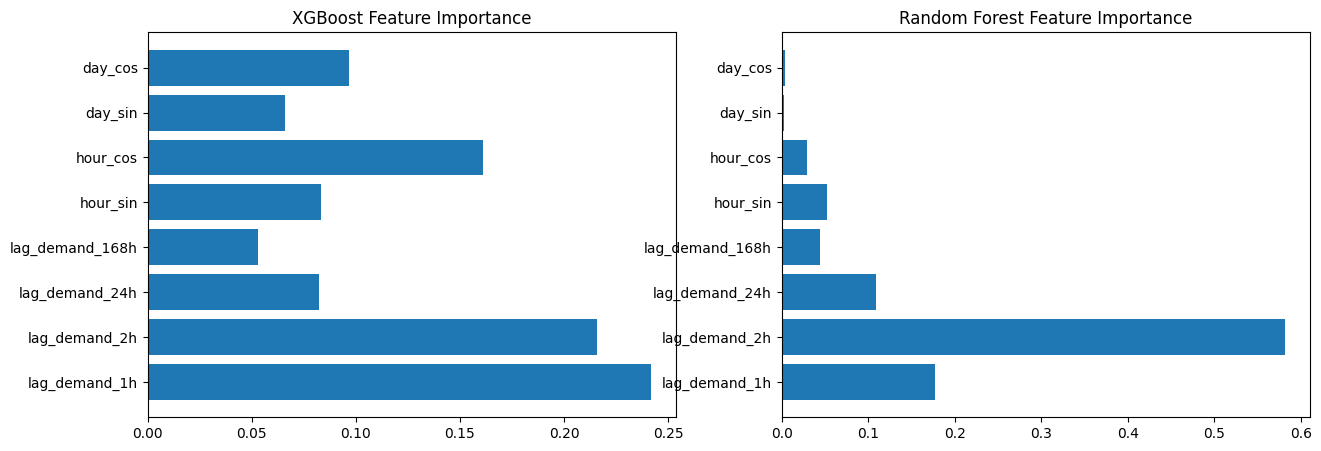

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load data
df = pd.read_parquet('../dataset/processed/engineered_features.parquet')
print(f"Loaded {len(df)} rows for training.")

# Define features and target
features_cols = ['lag_demand_1h', 'lag_demand_2h', 'lag_demand_24h', 'lag_demand_168h', 
                 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
target_col = 'total_demand'

# Split
train_df = df.iloc[:int(len(df)*0.8)]
test_df = df.iloc[int(len(df)*0.8):]
X_train, y_train = train_df[features_cols], train_df[target_col]
X_test, y_test = test_df[features_cols], test_df[target_col]

# Models dictionary
models = {}

# 1. XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=7, n_jobs=-1)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1)
rf.fit(X_train, y_train)
models['RandomForest'] = rf

# Analysis: Feature Importance for Trees
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].barh(features_cols, xgb.feature_importances_)
ax[0].set_title('XGBoost Feature Importance')
ax[1].barh(features_cols, rf.feature_importances_)
ax[1].set_title('Random Forest Feature Importance')
plt.show()